# EDA Lengkap — Student Placement System (SSDC)
Notebook ini mengikuti struktur **6 bagian** sesuai rincian yang sudah disepakati, mencakup ±30 poin analisis untuk BT-01 s.d. BT-08.

**Cara pakai:** jalankan sel dari atas ke bawah (Shift+Enter). Tiap bagian diawali sel markdown berisi tujuan analisis, diakhiri sel markdown berisi **catatan insight** (apa yang terkonfirmasi, apa yang TIDAK terbukti — supaya kamu tidak memaksakan cerita yang tidak didukung data).

**3 catatan struktural penting (baca dulu):**
1. `bidang_studi_dibutuhkan` (talent_request) dan `bidang_studi_dicari` (tracking_company) bisa berisi **multi-value dalam satu string** (`"Informatika, Sistem Informasi"`) — wajib di-split sebelum dibandingkan dengan `program_studi` (single value).
2. `progress_student` dan `rejection` (tracking_student) itu **1:1 mapping**, bukan dua dimensi independen — `Ghosting` di progress_student SELALU `rejection='Ghosting'` (atau kadang `Finish` untuk kasus lama yang ditutup). Jangan cross-tab keduanya seolah independen.
3. Semua FK/PK antar 6 tabel 100% bersih (no orphan, no duplicate) — sudah divalidasi.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

company = pd.read_csv('data/clean/company.csv')
tc = pd.read_csv('data/clean/tracking_company.csv')
sa = pd.read_csv('data/clean/student_all.csv')
tr = pd.read_csv('data/clean/talent_request.csv')
ss = pd.read_csv('data/clean/status_student.csv')
ts = pd.read_csv('data/clean/tracking_student.csv')

for df, col in [(company,'created_at'), (tr,'request_date'), (ss,'sync_date'),
                 (tc,'request_date'), (tc,'send_date'), (ts,'last_update')]:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Semua tabel loaded:", {n: d.shape for n,d in
      [('company',company),('tracking_company',tc),('student_all',sa),
       ('talent_request',tr),('status_student',ss),('tracking_student',ts)]})


Semua tabel loaded: {'company': (1500, 9), 'tracking_company': (12000, 13), 'student_all': (25000, 10), 'talent_request': (12000, 19), 'status_student': (25000, 15), 'tracking_student': (41600, 11)}


---
# BAGIAN 1 — Profil Dasar Tiap Tabel
Tujuan: kenalan dulu sama bentuk tiap tabel sebelum masuk analisis lintas-tabel yang lebih kompleks.

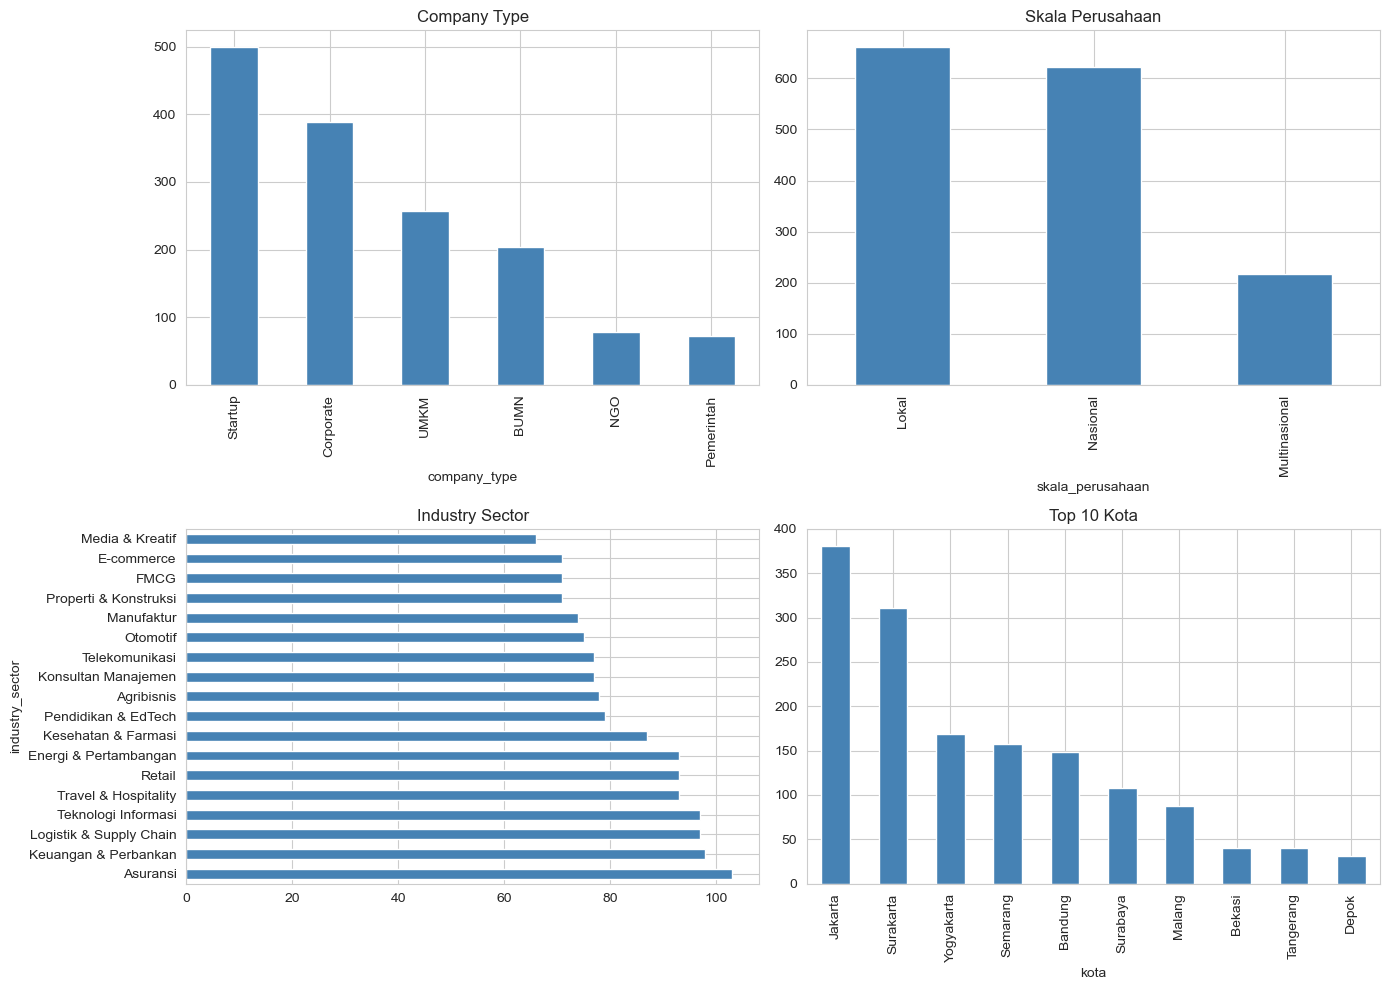

In [14]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
company.company_type.value_counts().plot(kind='bar', ax=axes[0,0], title='Company Type', color='steelblue')
company.skala_perusahaan.value_counts().plot(kind='bar', ax=axes[0,1], title='Skala Perusahaan', color='steelblue')
company.industry_sector.value_counts().plot(kind='barh', ax=axes[1,0], title='Industry Sector', color='steelblue')
company.kota.value_counts().head(10).plot(kind='bar', ax=axes[1,1], title='Top 10 Kota', color='steelblue')
plt.tight_layout()
plt.show()


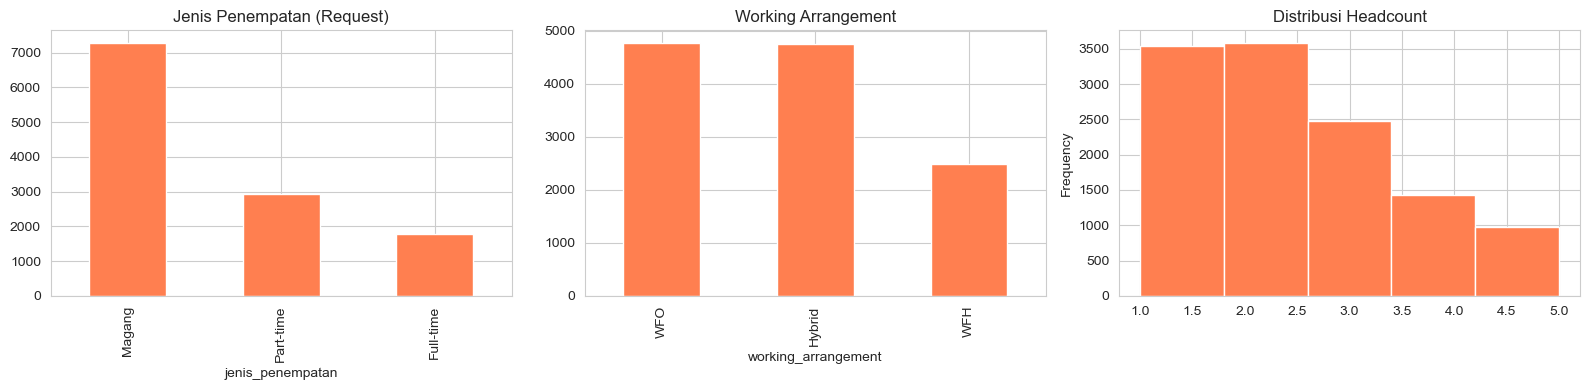

count    12000.000000
mean         2.393083
std          1.245404
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: headcount, dtype: float64


In [15]:
fig, axes = plt.subplots(1,3, figsize=(16,4))
tr.jenis_penempatan.value_counts().plot(kind='bar', ax=axes[0], title='Jenis Penempatan (Request)', color='coral')
tr.working_arrangement.value_counts().plot(kind='bar', ax=axes[1], title='Working Arrangement', color='coral')
tr.headcount.plot(kind='hist', bins=5, ax=axes[2], title='Distribusi Headcount', color='coral')
plt.tight_layout()
plt.show()
print(tr.headcount.describe())


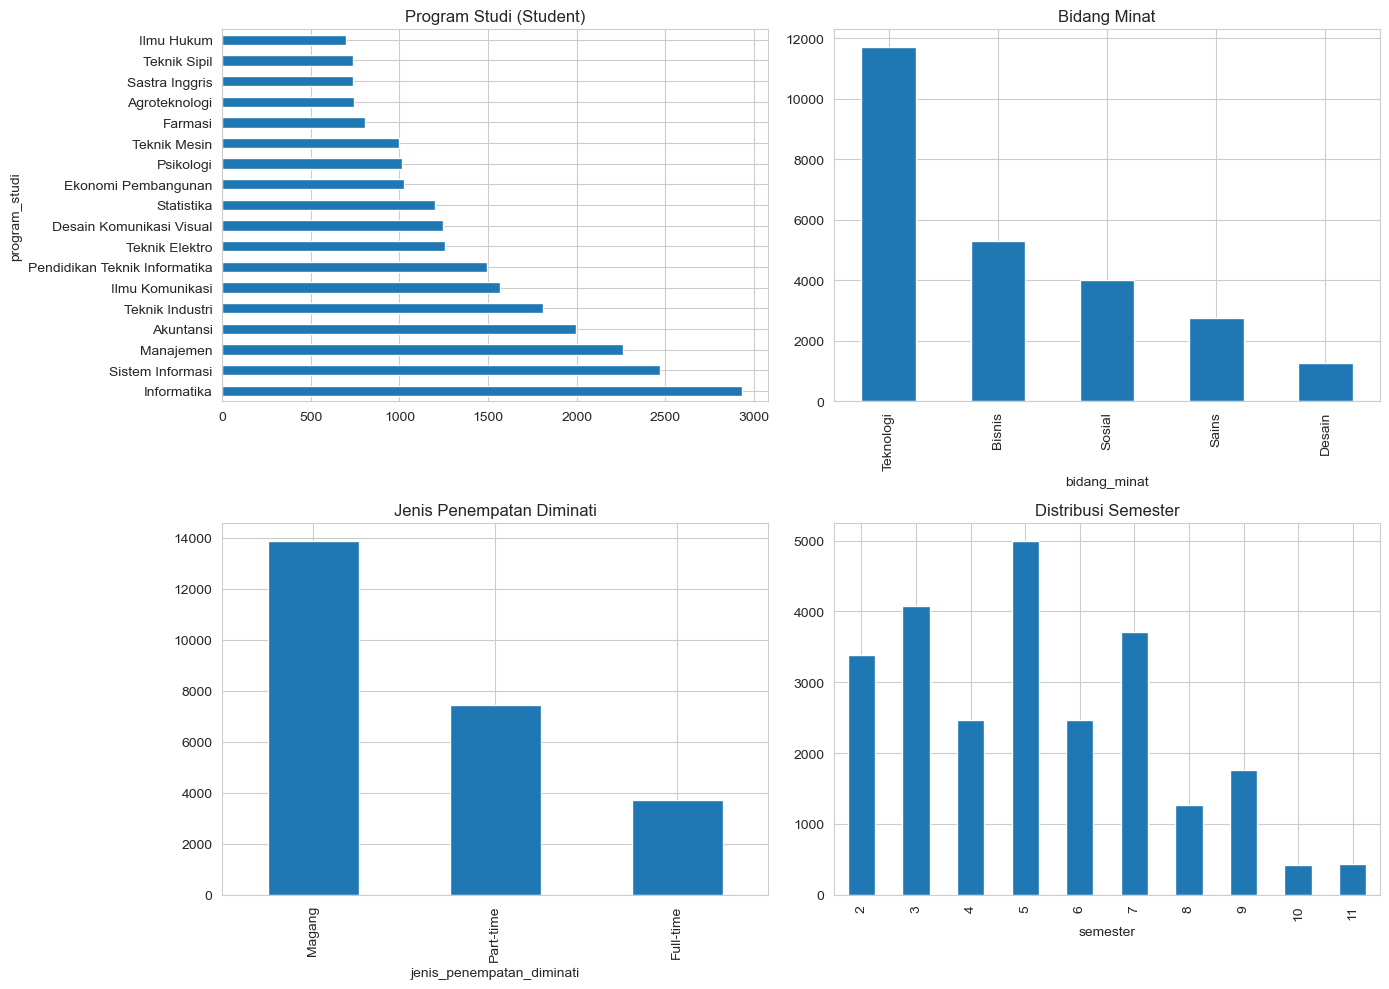

In [16]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
sa.program_studi.value_counts().plot(kind='barh', ax=axes[0,0], title='Program Studi (Student)')
sa.bidang_minat.value_counts().plot(kind='bar', ax=axes[0,1], title='Bidang Minat')
sa.jenis_penempatan_diminati.value_counts().plot(kind='bar', ax=axes[1,0], title='Jenis Penempatan Diminati')
sa.semester.value_counts().sort_index().plot(kind='bar', ax=axes[1,1], title='Distribusi Semester')
plt.tight_layout()
plt.show()


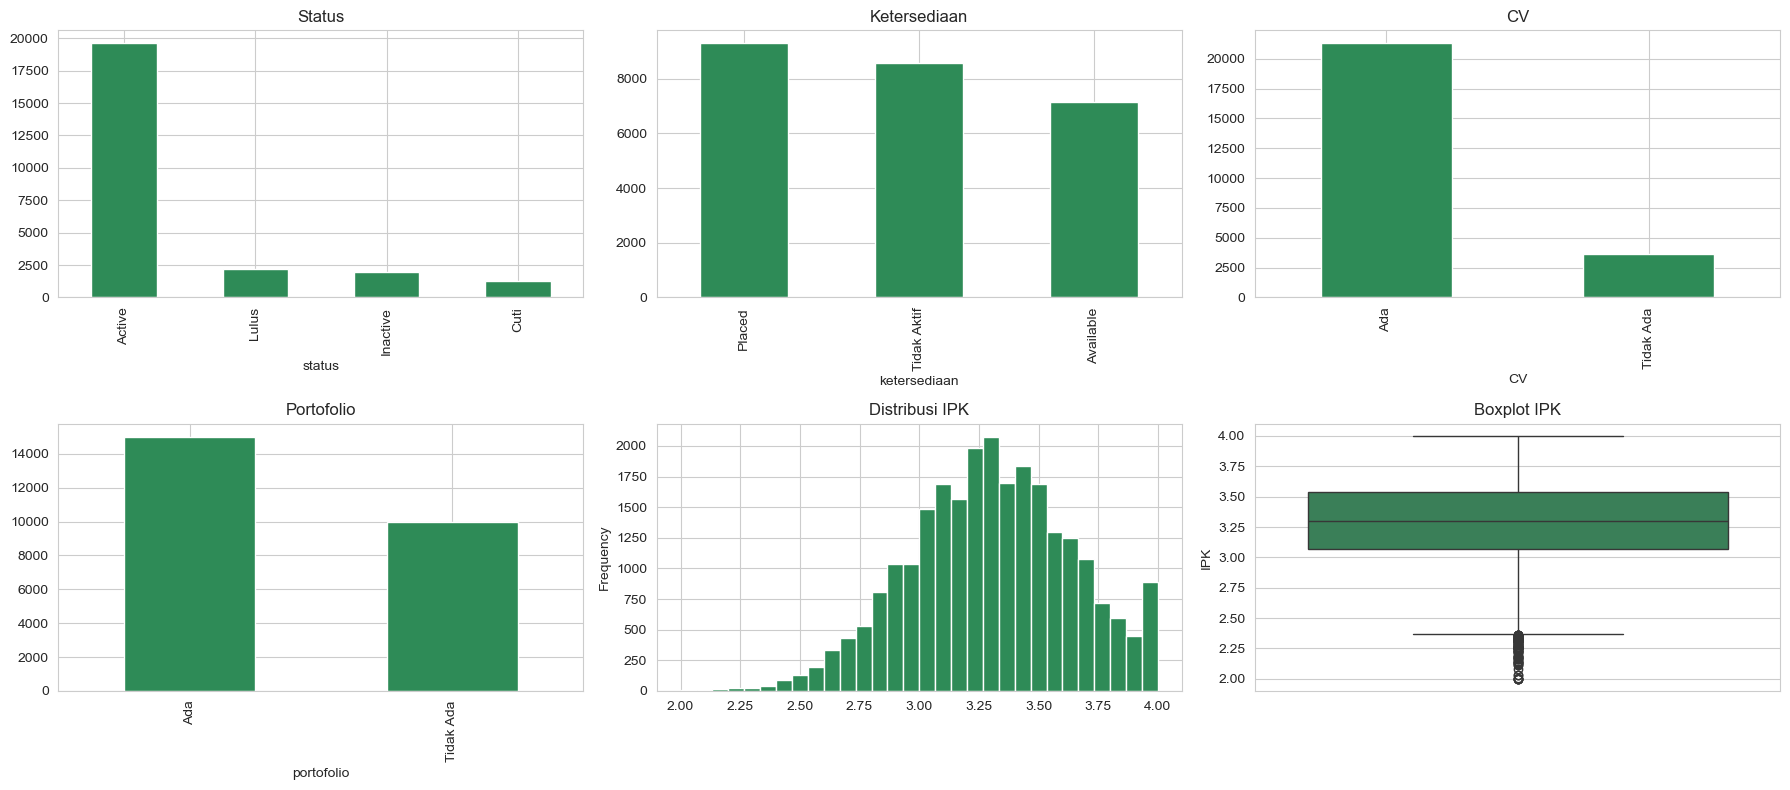

count    25000.000000
mean         3.298299
std          0.341807
min          2.000000
25%          3.070000
50%          3.300000
75%          3.540000
max          4.000000
Name: IPK, dtype: float64


In [17]:
fig, axes = plt.subplots(2,3, figsize=(18,8))
ss.status.value_counts().plot(kind='bar', ax=axes[0,0], title='Status', color='seagreen')
ss.ketersediaan.value_counts().plot(kind='bar', ax=axes[0,1], title='Ketersediaan', color='seagreen')
ss.CV.value_counts().plot(kind='bar', ax=axes[0,2], title='CV', color='seagreen')
ss.portofolio.value_counts().plot(kind='bar', ax=axes[1,0], title='Portofolio', color='seagreen')
ss.IPK.plot(kind='hist', bins=30, ax=axes[1,1], title='Distribusi IPK', color='seagreen')
sns.boxplot(y=ss.IPK, ax=axes[1,2], color='seagreen')
axes[1,2].set_title('Boxplot IPK')
plt.tight_layout()
plt.show()
print(ss.IPK.describe())


In [18]:
print("--- Rentang tanggal tiap tabel ---")
for name, df, col in [('company',company,'created_at'), ('talent_request',tr,'request_date'),
                       ('status_student',ss,'sync_date'), ('tracking_company (request)',tc,'request_date'),
                       ('tracking_company (send)',tc,'send_date'), ('tracking_student',ts,'last_update')]:
    print(f"{name:30s}: {df[col].min().date()} s.d. {df[col].max().date()}")

no_request = ~company.id_company.isin(tr.id_company)
print(f"\nPerusahaan terdaftar tapi tidak pernah request: {no_request.sum()} ({no_request.mean():.1%}) -- minor, bukan masalah signifikan")


--- Rentang tanggal tiap tabel ---
company                       : 2022-01-02 s.d. 2024-12-31
talent_request                : 2023-02-01 s.d. 2025-01-31
status_student                : 2023-02-01 s.d. 2025-01-31
tracking_company (request)    : 2023-02-01 s.d. 2025-01-31
tracking_company (send)       : 2023-02-04 s.d. 2025-02-21
tracking_student              : 2023-02-08 s.d. 2025-05-17

Perusahaan terdaftar tapi tidak pernah request: 5 (0.3%) -- minor, bukan masalah signifikan


**Catatan Bagian 1:**
- `company.created_at` (2022-2024) mendahului tabel transaksional lain (mulai 2023) — wajar, perusahaan daftar dulu baru request.
- Hanya 0.3% perusahaan yang terdaftar tapi tidak pernah mengajukan request — bukan masalah data, cukup dicatat saja.
- Semua distribusi kategorikal terlihat masuk akal, tidak ada kategori aneh/typo yang mencurigakan.
- IPK berkisar 2.00–4.00, median 3.30 — realistis untuk populasi mahasiswa aktif.

---
# BAGIAN 2 — Kelayakan Mahasiswa (BT-06)
Tujuan: bangun funnel bertingkat kelayakan, cari tahu di prodi mana bottleneck-nya, dan uji dugaan "IPK rendah = tidak available".

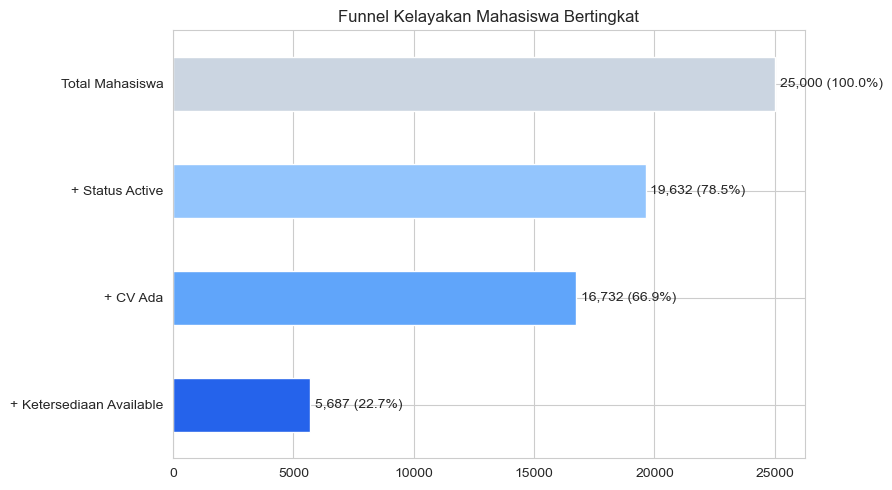

Total Mahasiswa             25000
+ Status Active             19632
+ CV Ada                    16732
+ Ketersediaan Available     5687
dtype: int64


In [19]:
total = len(ss)
step1 = ss[ss.status == 'Active']
step2 = step1[step1.CV == 'Ada']
step3 = step2[step2.ketersediaan == 'Available']

funnel_data = pd.Series({
    'Total Mahasiswa': total,
    '+ Status Active': len(step1),
    '+ CV Ada': len(step2),
    '+ Ketersediaan Available': len(step3),
})

fig, ax = plt.subplots(figsize=(9,5))
funnel_data.plot(kind='barh', ax=ax, color=['#cbd5e1','#93c5fd','#60a5fa','#2563eb'])
for i, v in enumerate(funnel_data):
    ax.text(v+200, i, f"{v:,} ({v/total:.1%})", va='center')
ax.set_title('Funnel Kelayakan Mahasiswa Bertingkat')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(funnel_data)


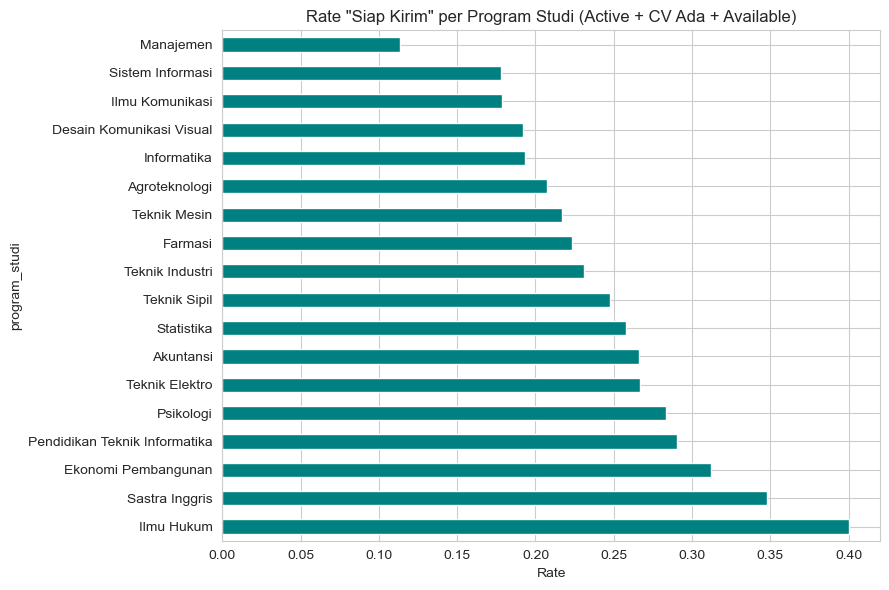

,total,siap_kirim,rate_siap_kirim
program_studi,,,
Ilmu Hukum,700,280,0.400000
Sastra Inggris,736,256,0.347826
Ekonomi Pembangunan,1025,320,0.312195
Pendidikan Teknik Informatika,1495,434,0.290301
Psikologi,1014,287,0.283037
Teknik Elektro,1255,335,0.266932
Akuntansi,1997,531,0.265899
Statistika,1202,310,0.257903
Teknik Sipil,735,182,0.247619


In [20]:
funnel_prodi = pd.DataFrame({
    'total': ss.groupby('program_studi').size(),
    'siap_kirim': ss[(ss.status=='Active')&(ss.CV=='Ada')&(ss.ketersediaan=='Available')].groupby('program_studi').size(),
}).fillna(0)
funnel_prodi['rate_siap_kirim'] = funnel_prodi['siap_kirim'] / funnel_prodi['total']
funnel_prodi = funnel_prodi.sort_values('rate_siap_kirim', ascending=False)

fig, ax = plt.subplots(figsize=(9,6))
funnel_prodi['rate_siap_kirim'].plot(kind='barh', ax=ax, color='teal')
ax.set_title('Rate "Siap Kirim" per Program Studi (Active + CV Ada + Available)')
ax.set_xlabel('Rate')
plt.tight_layout()
plt.show()
funnel_prodi


In [21]:
ct = pd.crosstab(ss.CV, ss.portofolio, margins=True)
print("Cross-tab CV x Portofolio (jumlah):")
print(ct)
print()
pct = pd.crosstab(ss.CV, ss.portofolio, normalize='all')*100
print("Dalam persen dari total:")
print(pct.round(1))


Cross-tab CV x Portofolio (jumlah):
portofolio    Ada  Tidak Ada    All
CV                                 
Ada         12810       8513  21323
Tidak Ada    2210       1467   3677
All         15020       9980  25000

Dalam persen dari total:
portofolio   Ada  Tidak Ada
CV                         
Ada         51.2       34.1
Tidak Ada    8.8        5.9


/var/folders/jf/zt84ffp55fvc4tdmq49nrt9c0000gn/T/ipykernel_7013/3210470481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ss, x='ketersediaan', y='IPK', ax=ax, palette='Set2')


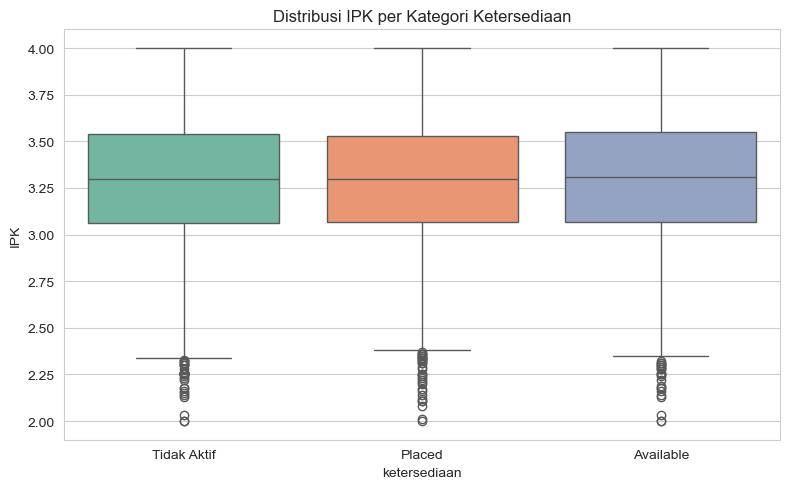

               count      mean   50%       std
ketersediaan                                  
Available     7135.0  3.303575  3.31  0.345949
Placed        9301.0  3.295519  3.30  0.338253
Tidak Aktif   8564.0  3.296922  3.30  0.342167


In [22]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=ss, x='ketersediaan', y='IPK', ax=ax, palette='Set2')
ax.set_title('Distribusi IPK per Kategori Ketersediaan')
plt.tight_layout()
plt.show()
print(ss.groupby('ketersediaan').IPK.describe()[['count','mean','50%','std']])


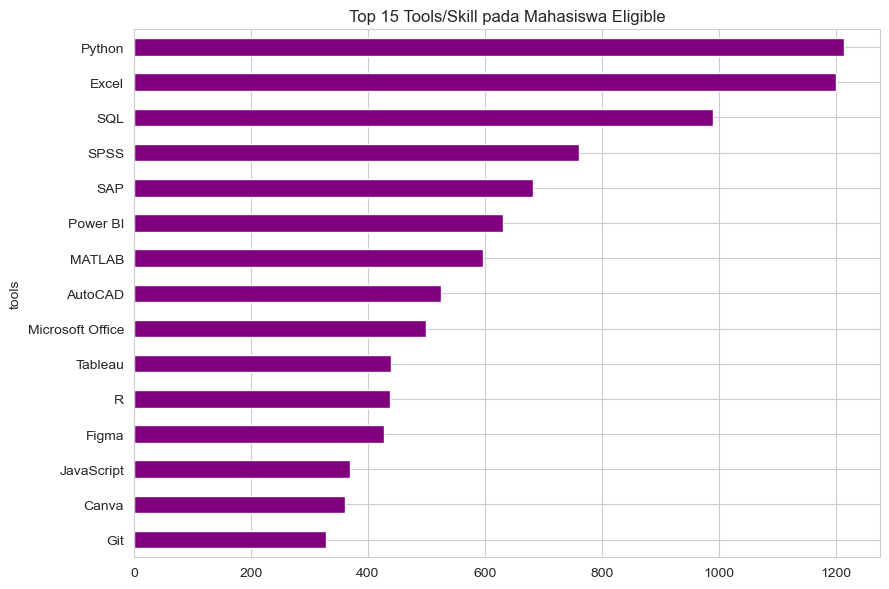

In [23]:
eligible_mask = (ss.status=='Active')&(ss.CV=='Ada')&(ss.ketersediaan=='Available')
tools_elig = ss[eligible_mask].tools.dropna().str.split(',').explode().str.strip()
fig, ax = plt.subplots(figsize=(9,6))
tools_elig.value_counts().head(15).plot(kind='barh', ax=ax, color='purple')
ax.set_title('Top 15 Tools/Skill pada Mahasiswa Eligible')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Catatan Bagian 2:**
- Funnel bertingkat: 25.000 → 78.5% Active → 66.9% +CV Ada → **hanya 22.7% yang benar-benar "siap kirim"** (Active + CV Ada + Available).
- **Manajemen** adalah prodi dengan rate siap-kirim TERENDAH (11.3%), meski jumlah mahasiswanya besar — ini penting karena nanti dipasangkan dengan Bagian 5/6 soal demand tinggi di prodi yang sama.
- **Ilmu Hukum & Sastra Inggris** justru rate siap-kirim tertinggi (~35-40%) meski populasinya kecil.
- Cross-tab CV×portofolio: **34.1%** mahasiswa punya CV tapi TIDAK punya portofolio — ini gap konkret yang bisa diangkat sebagai rekomendasi (dorong pembuatan portofolio).
- **Dugaan "IPK rendah → tidak available" TIDAK TERBUKTI** — distribusi IPK antara kelompok Available dan Tidak Aktif nyaris identik (median 3.31 vs 3.30). Jangan paksakan narasi ini di dashboard.

---
# BAGIAN 3 — Beban Proses & Ghosting (BT-02, BT-05)
Tujuan: pahami beban kerja per mahasiswa/posisi, cari tahap mana yang paling lama macet, dan analisis pola ghosting.

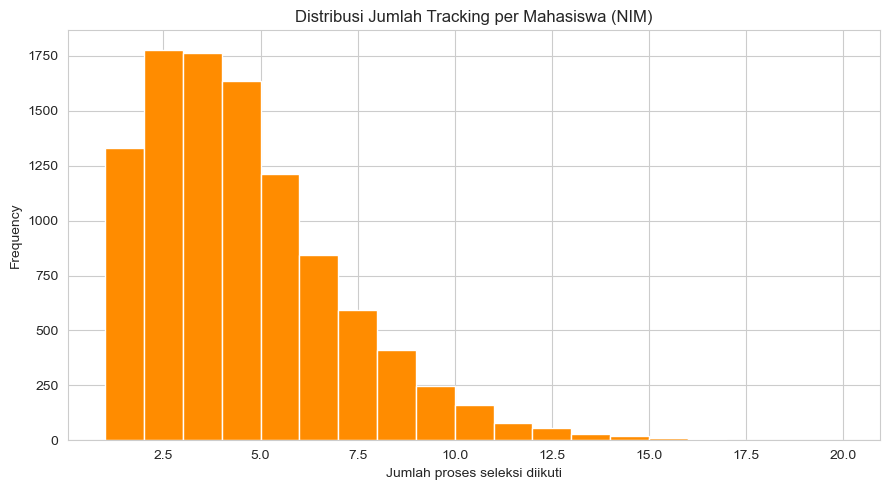

count    10174.000000
mean         4.088854
std          2.506449
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         19.000000
dtype: float64
% mahasiswa dengan >=3 proses sekaligus: 69.5%


In [24]:
per_nim = ts.groupby('NIM').size()
fig, ax = plt.subplots(figsize=(9,5))
per_nim.plot(kind='hist', bins=range(1,21), ax=ax, color='darkorange')
ax.set_title('Distribusi Jumlah Tracking per Mahasiswa (NIM)')
ax.set_xlabel('Jumlah proses seleksi diikuti')
plt.tight_layout()
plt.show()
print(per_nim.describe())
print(f"% mahasiswa dengan >=3 proses sekaligus: {(per_nim>=3).mean():.1%}")


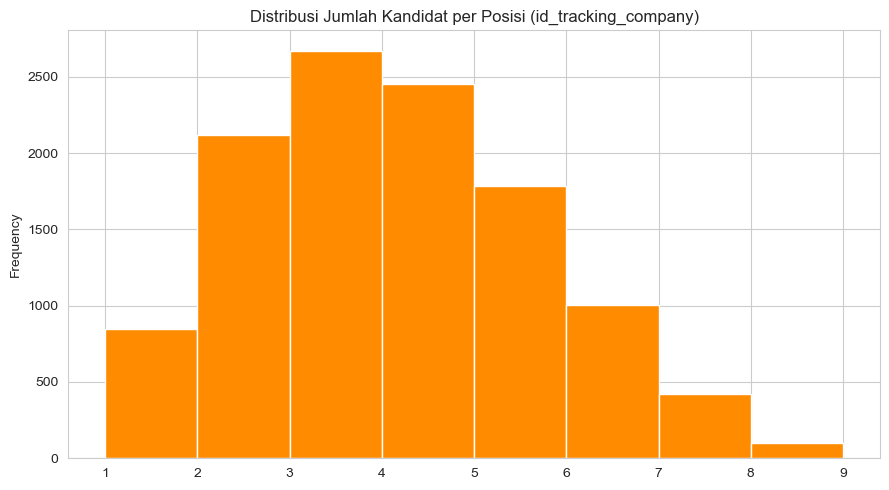

count    11402.000000
mean         3.648483
std          1.582210
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          8.000000
dtype: float64


In [25]:
per_tc = ts.groupby('id_tracking_company').size()
fig, ax = plt.subplots(figsize=(9,5))
per_tc.plot(kind='hist', bins=range(1,10), ax=ax, color='darkorange')
ax.set_title('Distribusi Jumlah Kandidat per Posisi (id_tracking_company)')
plt.tight_layout()
plt.show()
print(per_tc.describe())


/var/folders/jf/zt84ffp55fvc4tdmq49nrt9c0000gn/T/ipykernel_7013/1192659633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ts_time, y='progress_student', x='days_in_process', order=order, ax=ax, palette='coolwarm')


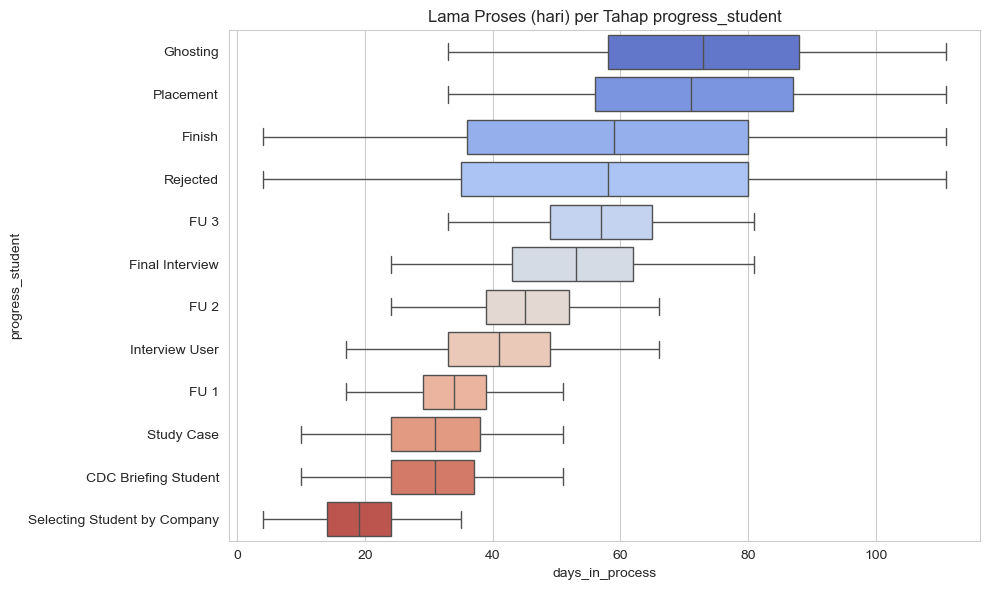

In [26]:
ts_time = ts.merge(tc[['id_tracking_company','request_date']], on='id_tracking_company', how='left')
ts_time['days_in_process'] = (ts_time['last_update'] - ts_time['request_date']).dt.days

order = ts_time.groupby('progress_student').days_in_process.mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=ts_time, y='progress_student', x='days_in_process', order=order, ax=ax, palette='coolwarm')
ax.set_title('Lama Proses (hari) per Tahap progress_student')
plt.tight_layout()
plt.show()


In [27]:
ghost = ts_time[ts_time.rejection == 'Ghosting']
print("Tahap progress_student untuk record dengan rejection='Ghosting':")
print(ghost.progress_student.value_counts())
print()
print("CATATAN: karena progress_student & rejection adalah mapping 1:1,")
print("pertanyaan 'ghosting terjadi di FU1/FU2/FU3 mana' TIDAK BISA dijawab langsung --")
print("progress_student='Ghosting' sudah jadi kategori final tersendiri, bukan sub-tahap dari FU.")


Tahap progress_student untuk record dengan rejection='Ghosting':
progress_student
Ghosting    2905
Finish       516
Name: count, dtype: int64

CATATAN: karena progress_student & rejection adalah mapping 1:1,
pertanyaan 'ghosting terjadi di FU1/FU2/FU3 mana' TIDAK BISA dijawab langsung --
progress_student='Ghosting' sudah jadi kategori final tersendiri, bukan sub-tahap dari FU.


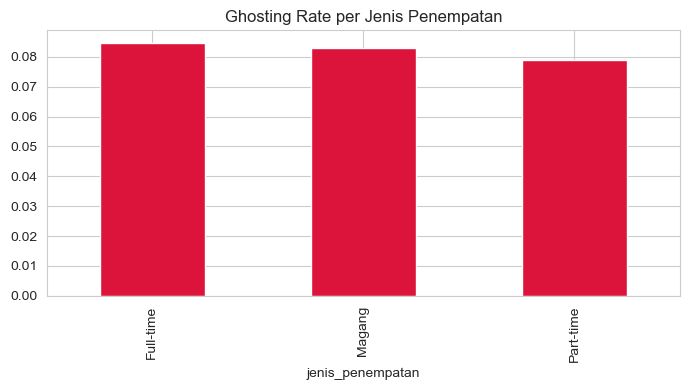

                  total  ghosting      rate
jenis_penempatan                           
Full-time          6311       534  0.084614
Magang            25167      2089  0.083006
Part-time         10122       798  0.078838


In [28]:
gh_jp = ts_time.groupby('jenis_penempatan').agg(total=('id_tracking_student','count'),
                                                    ghosting=('rejection', lambda x:(x=='Ghosting').sum()))
gh_jp['rate'] = gh_jp.ghosting/gh_jp.total
fig, ax = plt.subplots(figsize=(7,4))
gh_jp['rate'].plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Ghosting Rate per Jenis Penempatan')
plt.tight_layout()
plt.show()
print(gh_jp)


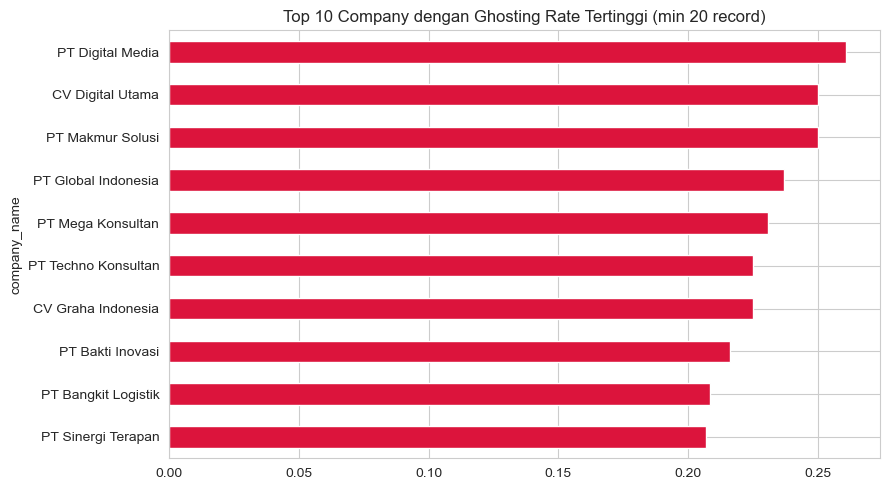

,total,ghosting,rate
company_name,,,
PT Digital Media,23,6,0.260870
CV Digital Utama,20,5,0.250000
PT Makmur Solusi,20,5,0.250000
PT Global Indonesia,38,9,0.236842
PT Mega Konsultan,26,6,0.230769
PT Techno Konsultan,40,9,0.225000
CV Graha Indonesia,40,9,0.225000
PT Bakti Inovasi,37,8,0.216216
PT Bangkit Logistik,24,5,0.208333


In [29]:
ts_comp = ts_time.merge(tc[['id_tracking_company','id_company']], on='id_tracking_company', how='left')
ts_comp = ts_comp.merge(company[['id_company','company_name','company_type']], on='id_company', how='left')
gh_comp = ts_comp.groupby('company_name').agg(total=('id_tracking_student','count'),
                                                ghosting=('rejection', lambda x:(x=='Ghosting').sum()))
gh_comp = gh_comp[gh_comp.total>=20]
gh_comp['rate'] = gh_comp.ghosting/gh_comp.total
top_gh = gh_comp.sort_values('rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9,5))
top_gh['rate'].plot(kind='barh', ax=ax, color='crimson')
ax.set_title('Top 10 Company dengan Ghosting Rate Tertinggi (min 20 record)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
top_gh


In [30]:
print("Lama proses (hari): Ghosting vs Placement")
comp_days = pd.DataFrame({
    'Ghosting': ts_time[ts_time.rejection=='Ghosting'].days_in_process.describe(),
    'Placement': ts_time[ts_time.rejection=='Placement'].days_in_process.describe(),
})
print(comp_days)


Lama proses (hari): Ghosting vs Placement
          Ghosting    Placement
count  3421.000000  8955.000000
mean     70.074247    69.443663
std      20.744429    20.572894
min       4.000000     5.000000
25%      55.000000    54.000000
50%      71.000000    70.000000
75%      87.000000    86.000000
max     111.000000   111.000000


**Catatan Bagian 3:**
- Rata-rata mahasiswa mengikuti **4.1 proses seleksi sekaligus**, dan **69.5%** mengikuti ≥3 proses bersamaan — beban monitoring per mahasiswa memang tinggi, mengonfirmasi tantangan BT-02.
- Tahap **`Selecting Student by Company`** paling cepat (median 19 hari), sedangkan **`Ghosting`** dan **`Placement`** (status akhir) butuh waktu terlama (median ~71-73 hari) — wajar karena keduanya endpoint proses.
- Ghosting rate per jenis_penempatan hampir sama (~7.9-8.5%) — **tidak ada pola signifikan** by jenis penempatan.
- Ghosting rate per company bervariasi 0%–26% — beberapa company (PT Digital Media, PT Makmur Solusi, dll) jauh di atas rata-rata dan layak masuk watch-list.
- **Dugaan "ghosting butuh waktu lebih lama sebelum menyerah" TIDAK TERBUKTI** — lama proses Ghosting (mean 70 hari) hampir sama dengan Placement (mean 69 hari).

---
# BAGIAN 4 — Funnel Hasil & Keberhasilan (BT-04, BT-07)
**Penting soal definisi:** placement rate di bagian ini dihitung dari record yang SUDAH final (exclude 'On Progress'). Ini beda dari "rate dari total keseluruhan" — pastikan pilih 1 definisi dan konsisten dipakai di semua chart dashboard.

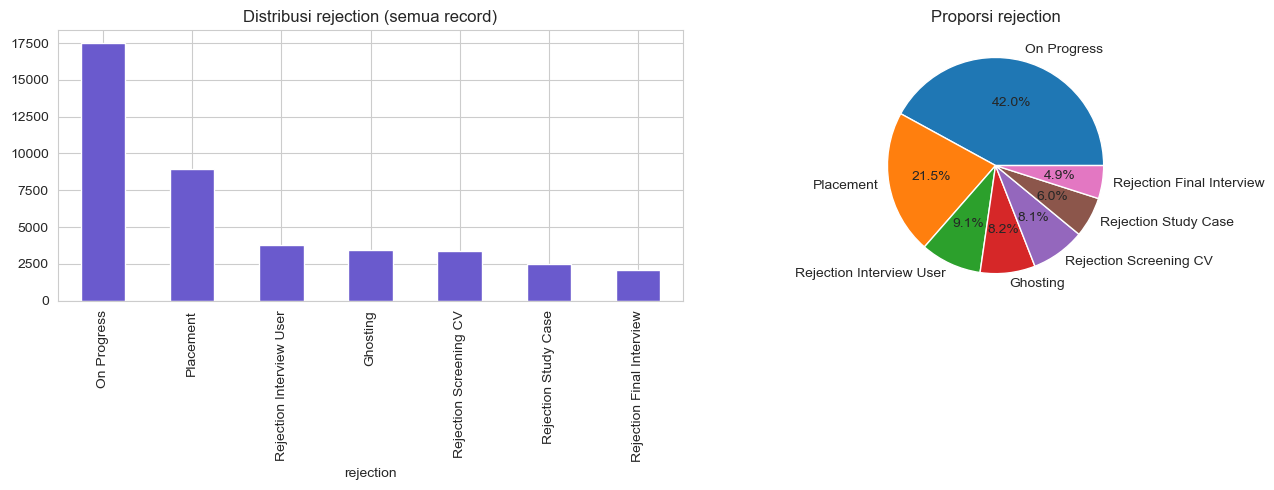

In [31]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
ts.rejection.value_counts().plot(kind='bar', ax=ax[0], color='slateblue', title='Distribusi rejection (semua record)')
ts.rejection.value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', title='Proporsi rejection')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()


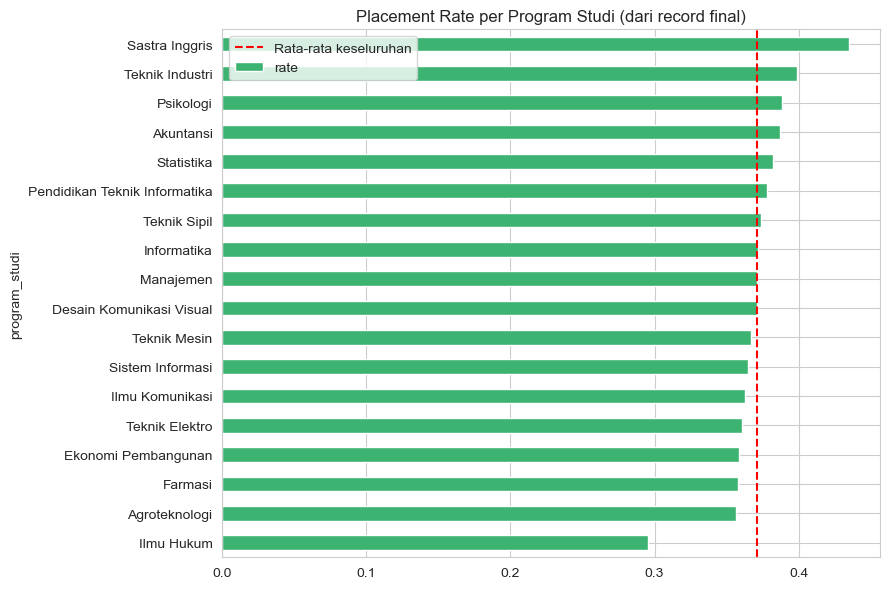

,total,placement,rate
program_studi,,,
Sastra Inggris,138,60,0.434783
Teknik Industri,1402,559,0.398716
Psikologi,566,220,0.388693
Akuntansi,1109,429,0.386835
Statistika,885,338,0.381921
Pendidikan Teknik Informatika,804,304,0.378109
Teknik Sipil,671,251,0.374069
Informatika,3183,1183,0.371662
Manajemen,4547,1689,0.371454


In [32]:
ts_full = ts.merge(sa[['NIM','program_studi']], on='NIM', how='left')
final = ts_full[ts_full.rejection != 'On Progress']

by_prodi = final.groupby('program_studi').agg(total=('id_tracking_student','count'),
                                                 placement=('rejection', lambda x:(x=='Placement').sum()))
by_prodi['rate'] = by_prodi.placement/by_prodi.total
by_prodi = by_prodi.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(9,6))
by_prodi['rate'].plot(kind='barh', ax=ax, color='mediumseagreen')
ax.axvline(final.rejection.eq('Placement').mean(), color='red', linestyle='--', label='Rata-rata keseluruhan')
ax.set_title('Placement Rate per Program Studi (dari record final)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
by_prodi


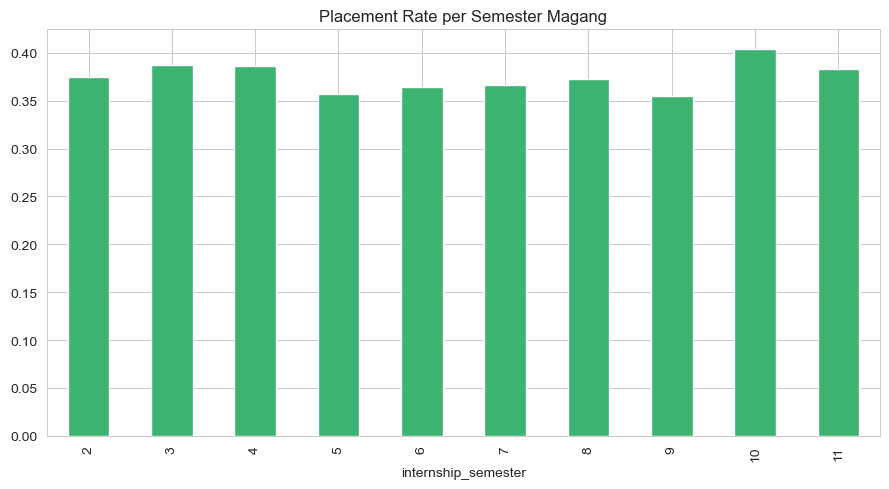

,total,placement,rate
internship_semester,,,
2,3381,1266,0.374445
3,4110,1593,0.387591
4,2289,884,0.386195
5,4755,1699,0.357308
6,2309,841,0.364227
7,3580,1310,0.365922
8,1220,455,0.372951
9,1680,597,0.355357
10,381,154,0.404199


In [33]:
by_sem = final.groupby('internship_semester').agg(total=('id_tracking_student','count'),
                                                      placement=('rejection', lambda x:(x=='Placement').sum()))
by_sem['rate'] = by_sem.placement/by_sem.total
fig, ax = plt.subplots(figsize=(9,5))
by_sem['rate'].plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Placement Rate per Semester Magang')
plt.tight_layout()
plt.show()
by_sem


In [34]:
by_jp = final.groupby('jenis_penempatan').agg(total=('id_tracking_student','count'),
                                                 placement=('rejection', lambda x:(x=='Placement').sum()))
by_jp['rate'] = by_jp.placement/by_jp.total
print(by_jp)


                  total  placement      rate
jenis_penempatan                            
Full-time          3606       1331  0.369107
Magang            14623       5431  0.371401
Part-time          5883       2193  0.372769


Range acceptance rate per company: 5.6% - 68.8%


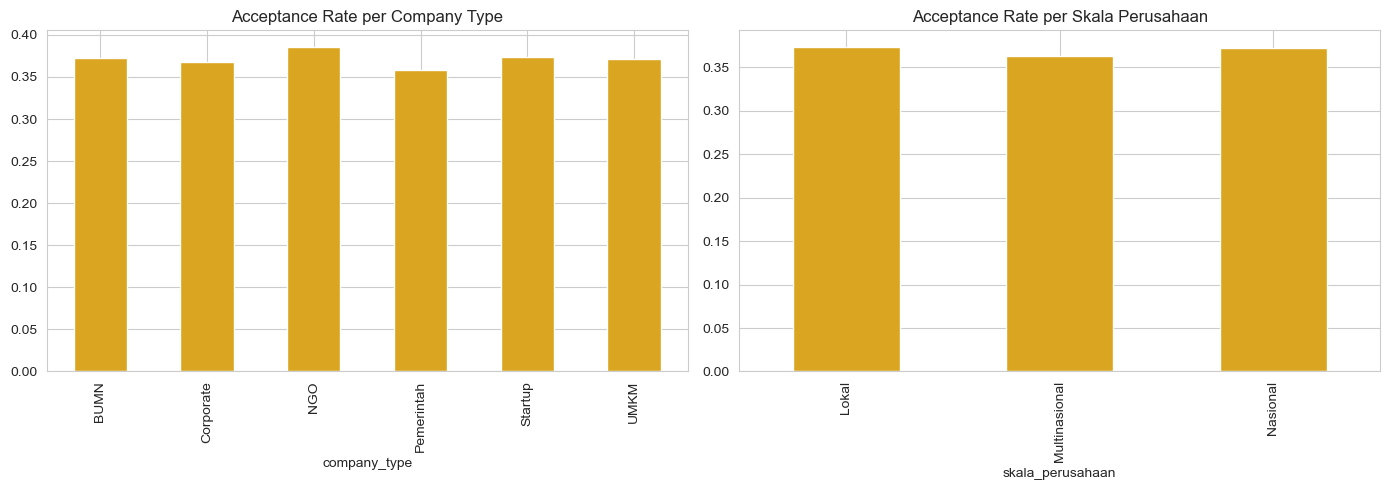

In [35]:
ts_comp2 = ts.merge(tc[['id_tracking_company','id_company']], on='id_tracking_company', how='left')
ts_comp2 = ts_comp2.merge(company[['id_company','company_name','company_type','skala_perusahaan']], on='id_company', how='left')
final_comp = ts_comp2[ts_comp2.rejection != 'On Progress']

acc_comp = final_comp.groupby('company_name').agg(total=('id_tracking_student','count'),
                                                     placement=('rejection', lambda x:(x=='Placement').sum()))
acc_comp = acc_comp[acc_comp.total>=15]
acc_comp['rate'] = acc_comp.placement/acc_comp.total
print(f"Range acceptance rate per company: {acc_comp['rate'].min():.1%} - {acc_comp['rate'].max():.1%}")

fig, axes = plt.subplots(1,2, figsize=(14,5))
by_type = final_comp.groupby('company_type').agg(total=('id_tracking_student','count'),
                                                   placement=('rejection', lambda x:(x=='Placement').sum()))
by_type['rate'] = by_type.placement/by_type.total
by_type['rate'].plot(kind='bar', ax=axes[0], title='Acceptance Rate per Company Type', color='goldenrod')

by_skala = final_comp.groupby('skala_perusahaan').agg(total=('id_tracking_student','count'),
                                                        placement=('rejection', lambda x:(x=='Placement').sum()))
by_skala['rate'] = by_skala.placement/by_skala.total
by_skala['rate'].plot(kind='bar', ax=axes[1], title='Acceptance Rate per Skala Perusahaan', color='goldenrod')
plt.tight_layout()
plt.show()


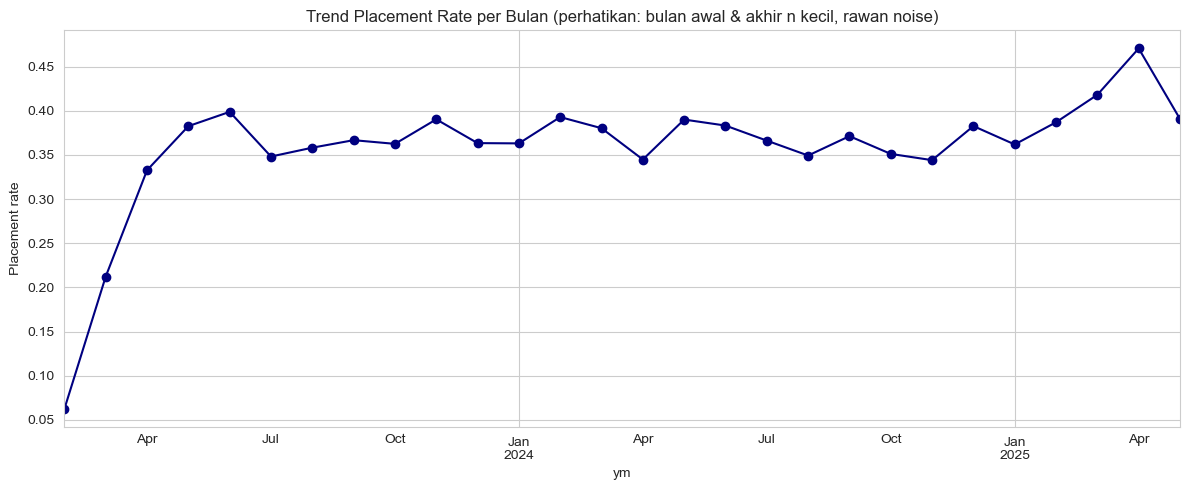

         total  placement      rate
ym                                 
2023-02     16          1  0.062500
2023-03    179         38  0.212291
2023-04    463        154  0.332613
2023-05    766        293  0.382507
2023-06    760        303  0.398684
2023-07    721        251  0.348128
2023-08    860        308  0.358140
2023-09    941        345  0.366631
2023-10   1087        394  0.362466
2023-11   1084        423  0.390221
2023-12   1101        400  0.363306
2024-01   1146        416  0.363002
2024-02   1026        403  0.392788
2024-03   1039        395  0.380173
2024-04    992        342  0.344758
2024-05    936        365  0.389957
2024-06    903        346  0.383167
2024-07    874        320  0.366133
2024-08    942        329  0.349257
2024-09    951        353  0.371188
2024-10   1145        402  0.351092
2024-11   1154        397  0.344021
2024-12   1286        492  0.382582
2025-01   1230        445  0.361789
2025-02   1039        402  0.386910
2025-03    933        390  0

In [36]:
ts_trend = ts.copy()
ts_trend['ym'] = ts_trend.last_update.dt.to_period('M')
trend = ts_trend[ts_trend.rejection!='On Progress'].groupby('ym').agg(
    total=('id_tracking_student','count'), placement=('rejection', lambda x:(x=='Placement').sum()))
trend['rate'] = trend.placement/trend.total

fig, ax = plt.subplots(figsize=(12,5))
trend['rate'].plot(ax=ax, marker='o', color='navy')
ax.set_title('Trend Placement Rate per Bulan (perhatikan: bulan awal & akhir n kecil, rawan noise)')
ax.set_ylabel('Placement rate')
plt.tight_layout()
plt.show()
print(trend)


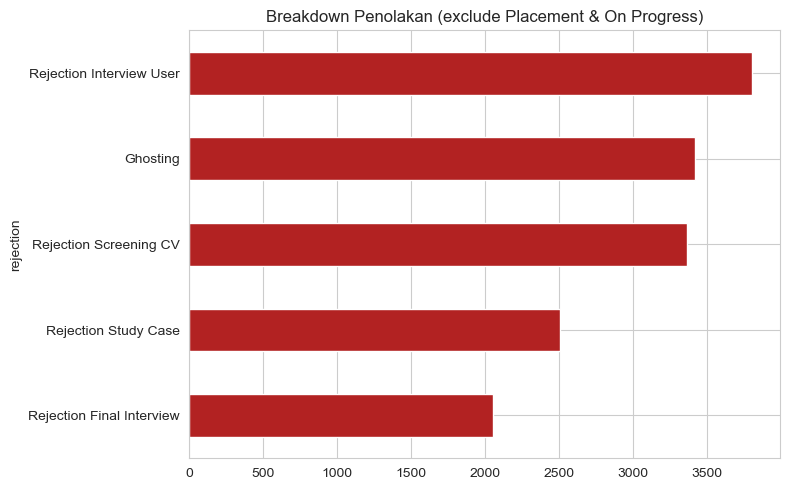

rejection
Rejection Interview User     3805
Ghosting                     3421
Rejection Screening CV       3368
Rejection Study Case         2509
Rejection Final Interview    2054
Name: count, dtype: int64


In [37]:
rejected_only = ts[~ts.rejection.isin(['Placement','On Progress'])]
fig, ax = plt.subplots(figsize=(8,5))
rejected_only.rejection.value_counts().plot(kind='barh', ax=ax, color='firebrick')
ax.set_title('Breakdown Penolakan (exclude Placement & On Progress)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(rejected_only.rejection.value_counts())


**Catatan Bagian 4:**
- Placement rate keseluruhan (dari record final) = **~37%**. On Progress masih 42% dari total — proporsi besar yang perlu terus dipantau (BT-02).
- Placement rate per prodi berkisar **29.6%–43.5%** — variasi ada tapi tidak drastis; Sastra Inggris tertinggi (n kecil, hati-hati overinterpret), Ilmu Hukum terendah.
- Placement rate per semester dan per jenis_penempatan **relatif flat** (~36-40%) — tidak ada pola kuat "semester lebih tinggi = lebih mudah diterima".
- Acceptance rate per company bervariasi luas (beberapa % hingga hampir 70%) — ini variasi yang layak diangkat sebagai insight per-company.
- **Rejection Interview User** adalah penyumbang penolakan terbesar (3805, ~29% dari semua non-placement/non-ongoing) — sinyal bahwa tahap interview user adalah titik gugur paling umum.
- Trend bulanan: kenaikan rate di Maret-Mei 2025 kemungkinan **noise** karena volume data di bulan-bulan itu kecil (n=933, 474, 64) — jangan overclaim sebagai tren nyata.

---
# BAGIAN 5 — Kualitas Matching (BT-01)
**Temuan paling signifikan ada di sini** — beberapa dugaan di rencana awal ternyata TIDAK sesuai realita data, jadi baca catatan di akhir bagian ini baik-baik.

In [38]:
tc2 = tc.dropna(subset=['list_nim']).copy()
tc2['NIM'] = tc2.list_nim.str.split(',')
sent = tc2.explode('NIM')
sent['NIM'] = sent['NIM'].str.strip().astype(int)
sent = sent.merge(sa[['NIM','program_studi','semester']], on='NIM', how='left')
sent = sent.merge(tr[['id_talent_req','minimum_semester','working_arrangement']], on='id_talent_req', how='left')
sent = sent.merge(company[['id_company','kota']].rename(columns={'kota':'kota_company'}), on='id_company', how='left')
sent = sent.merge(ss[['NIM','domisili']], on='NIM', how='left')

print(f"Total baris kandidat terkirim (expand list_nim): {len(sent)}")

sent['prodi_cocok'] = sent.apply(lambda r: r['program_studi'] in str(r['bidang_studi_dicari']), axis=1)
print(f"% prodi cocok dengan bidang_studi_dicari: {sent.prodi_cocok.mean():.2%}")


Total baris kandidat terkirim (expand list_nim): 41600
% prodi cocok dengan bidang_studi_dicari: 100.00%


% kandidat memenuhi syarat minimum_semester: 49.47%
% MELANGGAR syarat minimum_semester: 50.53%


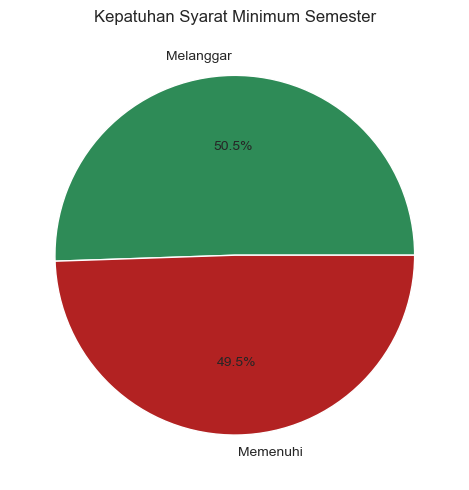

In [39]:
sent['semester_ok'] = sent['semester'] >= sent['minimum_semester']
print(f"% kandidat memenuhi syarat minimum_semester: {sent.semester_ok.mean():.2%}")
print(f"% MELANGGAR syarat minimum_semester: {(~sent.semester_ok).mean():.2%}")

fig, ax = plt.subplots(figsize=(6,5))
sent.semester_ok.value_counts().rename({True:'Memenuhi',False:'Melanggar'}).plot(kind='pie', ax=ax, autopct='%1.1f%%', colors=['seagreen','firebrick'])
ax.set_title('Kepatuhan Syarat Minimum Semester')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


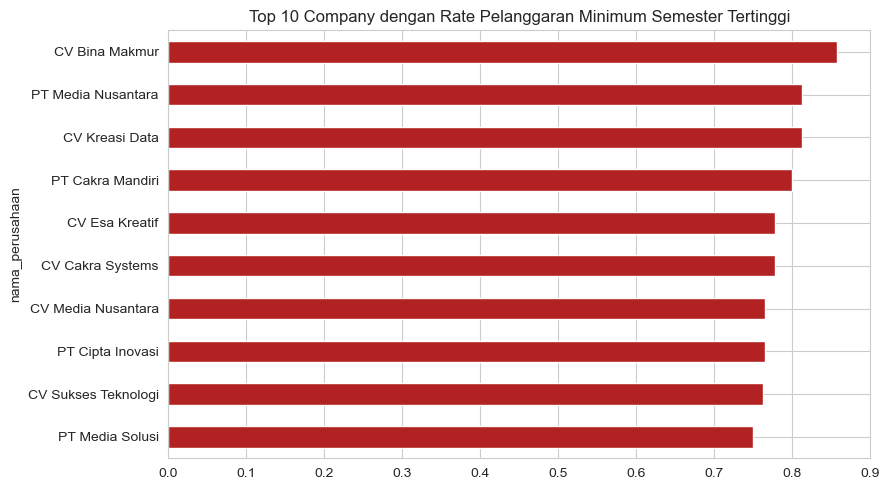

,total,violasi,rate
nama_perusahaan,,,
CV Bina Makmur,21,18,0.857143
PT Media Nusantara,16,13,0.812500
CV Kreasi Data,16,13,0.812500
PT Cakra Mandiri,15,12,0.800000
CV Esa Kreatif,18,14,0.777778
CV Cakra Systems,18,14,0.777778
CV Media Nusantara,17,13,0.764706
PT Cipta Inovasi,17,13,0.764706
CV Sukses Teknologi,21,16,0.761905


In [40]:
viol = sent.groupby('nama_perusahaan').agg(total=('NIM','count'), violasi=('semester_ok', lambda x:(~x).sum()))
viol = viol[viol.total>=15]
viol['rate'] = viol.violasi/viol.total
top_viol = viol.sort_values('rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9,5))
top_viol['rate'].plot(kind='barh', ax=ax, color='firebrick')
ax.set_title('Top 10 Company dengan Rate Pelanggaran Minimum Semester Tertinggi')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
top_viol


In [41]:
wfo = sent[sent.working_arrangement == 'WFO']
wfo_mismatch = (wfo['domisili'] != wfo['kota_company']).mean()
print(f"Kandidat dikirim ke posisi WFO: {len(wfo)}")
print(f"% domisili beda kota dengan company (WFO): {wfo_mismatch:.2%}")

# sanity check: bandingkan dgn Hybrid & WFH
by_arr = sent.groupby('working_arrangement').apply(lambda d: (d['domisili']!=d['kota_company']).mean())
print("\nMismatch rate per working_arrangement (sanity check apakah WFO beda dari WFH):")
print(by_arr)


Kandidat dikirim ke posisi WFO: 16542
% domisili beda kota dengan company (WFO): 88.42%

Mismatch rate per working_arrangement (sanity check apakah WFO beda dari WFH):
working_arrangement
Hybrid    0.883889
WFH       0.891302
WFO       0.884174
dtype: float64


/var/folders/jf/zt84ffp55fvc4tdmq49nrt9c0000gn/T/ipykernel_7013/3501243318.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_arr = sent.groupby('working_arrangement').apply(lambda d: (d['domisili']!=d['kota_company']).mean())


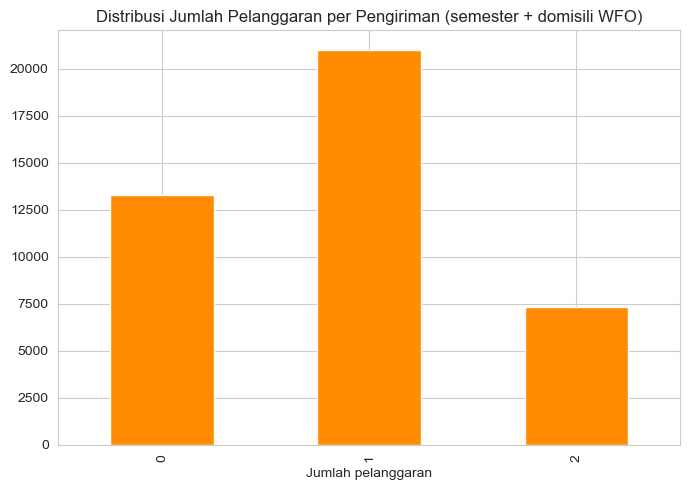

n_violations
0    31.923077
1    50.463942
2    17.612981
Name: proportion, dtype: float64


In [42]:
sent['viol_semester'] = ~sent['semester_ok']
sent['viol_domisili'] = (sent['working_arrangement']=='WFO') & (sent['domisili'] != sent['kota_company'])
sent['n_violations'] = sent[['viol_semester','viol_domisili']].sum(axis=1)

fig, ax = plt.subplots(figsize=(7,5))
sent.n_violations.value_counts().sort_index().plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Distribusi Jumlah Pelanggaran per Pengiriman (semester + domisili WFO)')
ax.set_xlabel('Jumlah pelanggaran')
plt.tight_layout()
plt.show()
print(sent.n_violations.value_counts(normalize=True).sort_index()*100)


**Catatan Bagian 5 (PENTING — baca sebelum presentasi):**
- **Prodi 100% cocok** dengan bidang_studi_dicari — terkonfirmasi, tidak ada masalah di sini.
- **50.5% kandidat yang dikirim TIDAK memenuhi syarat minimum_semester** — jauh dari asumsi awal ("sudah 100%, tinggal konfirmasi"). Ini temuan besar dan mengejutkan; layak jadi salah satu insight utama dashboard, dengan catatan: perlu dicek juga apakah field `minimum_semester` di talent_request memang dimaksudkan sebagai syarat keras (hard requirement) atau cuma rekomendasi/preferensi — ini asumsi bisnis yang sebaiknya dikonfirmasi ke dokumentasi asli / pembimbing lomba jika perlu.
- **88% kandidat WFO domisilinya beda kota** dengan perusahaan — TAPI ini rate hampir sama persis untuk Hybrid (88.4%) dan WFH (89.1%). Karena seharusnya WFH tidak butuh domisili cocok tapi WFO seharusnya butuh, kesamaan rate ini mengindikasikan domisili & lokasi company di dataset ini **kemungkinan besar tidak berkorelasi secara sengaja** (karakteristik data simulasi), bukan bukti kuat proses matching CDC mengabaikan domisili. **Sampaikan temuan ini dengan hati-hati** — angka valid, tapi interpretasi "CDC ceroboh soal lokasi" perlu disertai disclaimer ini.

---
# BAGIAN 6 — Manajemen Talent Request (BT-03)

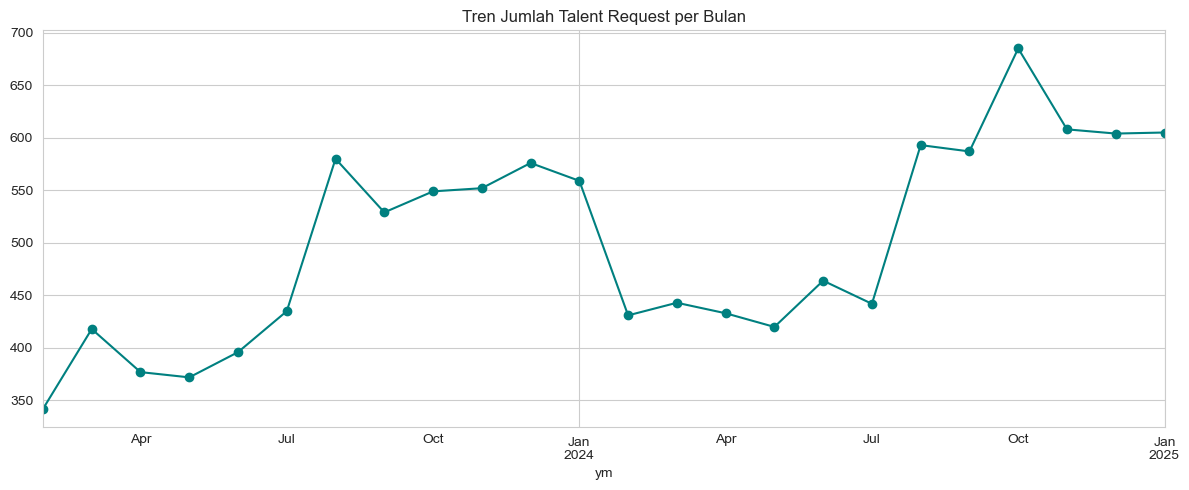

In [43]:
tr['ym'] = tr.request_date.dt.to_period('M')
fig, ax = plt.subplots(figsize=(12,5))
tr.groupby('ym').size().plot(ax=ax, marker='o', color='teal')
ax.set_title('Tren Jumlah Talent Request per Bulan')
plt.tight_layout()
plt.show()


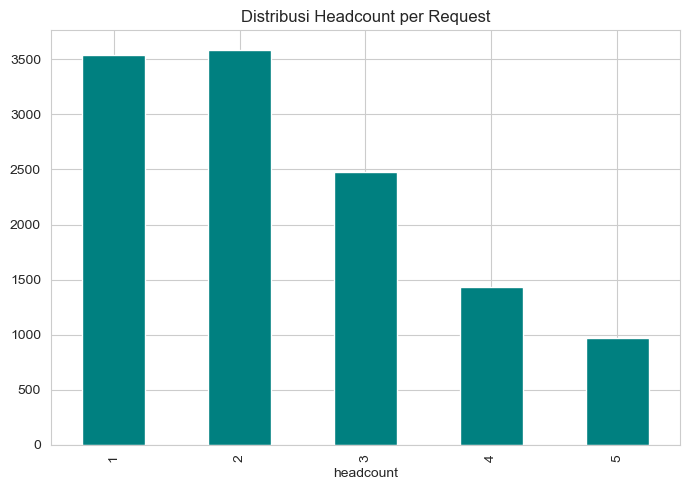

In [44]:
fig, ax = plt.subplots(figsize=(7,5))
tr.headcount.value_counts().sort_index().plot(kind='bar', ax=ax, color='teal')
ax.set_title('Distribusi Headcount per Request')
plt.tight_layout()
plt.show()


/var/folders/jf/zt84ffp55fvc4tdmq49nrt9c0000gn/T/ipykernel_7013/2579218562.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tc2, x='headcount_group', y='lead_time_days', ax=ax, palette='Blues')


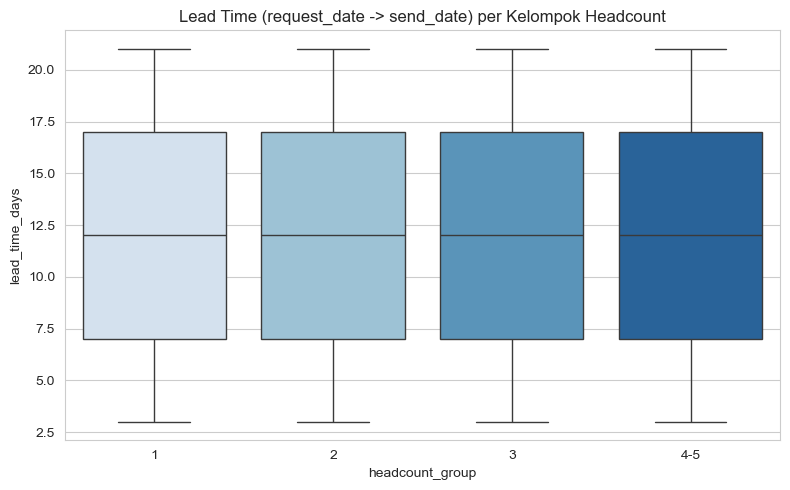

                  count       mean   50%       std
headcount_group                                   
1                3351.0  11.932557  12.0  5.518186
2                3399.0  11.908797  12.0  5.458596
3                2363.0  12.018197  12.0  5.512292
4-5              2289.0  12.008301  12.0  5.485631


/var/folders/jf/zt84ffp55fvc4tdmq49nrt9c0000gn/T/ipykernel_7013/2579218562.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tc2.groupby('headcount_group').lead_time_days.describe()[['count','mean','50%','std']])


In [45]:
tc2 = tc.dropna(subset=['send_date']).copy()
tc2 = tc2.merge(tr[['id_talent_req','headcount']], on='id_talent_req', how='left')
tc2['lead_time_days'] = (tc2['send_date'] - tc2['request_date']).dt.days
tc2['headcount_group'] = pd.cut(tc2['headcount'], bins=[0,1,2,3,10], labels=['1','2','3','4-5'])

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=tc2, x='headcount_group', y='lead_time_days', ax=ax, palette='Blues')
ax.set_title('Lead Time (request_date -> send_date) per Kelompok Headcount')
plt.tight_layout()
plt.show()
print(tc2.groupby('headcount_group').lead_time_days.describe()[['count','mean','50%','std']])


In [46]:
draft = tc[tc.progress=='Draft']
print(f"Total request masih Draft: {len(draft)} dari {len(tc)} ({len(draft)/len(tc):.2%})")
print()
print("Draft per jenis_penempatan:")
print(draft.jenis_penempatan.value_counts())

tc3 = tc.merge(tr[['id_talent_req','sumber_baris_form']], on='id_talent_req', how='left')
draft_by_source = tc3.groupby('sumber_baris_form').apply(lambda d: (d.progress=='Draft').mean())
print("\nDraft rate per sumber_baris_form:")
print(draft_by_source)


Total request masih Draft: 598 dari 12000 (4.98%)

Draft per jenis_penempatan:
jenis_penempatan
Magang       375
Part-time    146
Full-time     77
Name: count, dtype: int64

Draft rate per sumber_baris_form:
sumber_baris_form
Email           0.043097
Google Form     0.051886
Input Manual    0.044672
WhatsApp        0.054152
dtype: float64


/var/folders/jf/zt84ffp55fvc4tdmq49nrt9c0000gn/T/ipykernel_7013/3820279471.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  draft_by_source = tc3.groupby('sumber_baris_form').apply(lambda d: (d.progress=='Draft').mean())


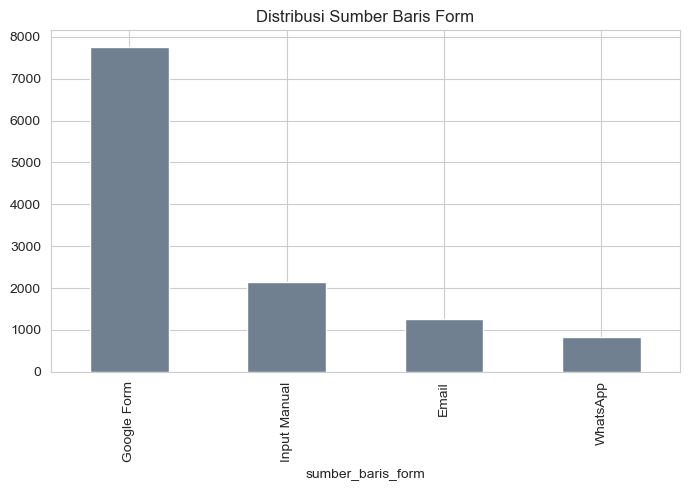

sumber_baris_form
Google Form     64.7
Input Manual    17.9
Email           10.4
WhatsApp         6.9
Name: proportion, dtype: float64


In [47]:
fig, ax = plt.subplots(figsize=(7,5))
tr.sumber_baris_form.value_counts().plot(kind='bar', ax=ax, color='slategray')
ax.set_title('Distribusi Sumber Baris Form')
plt.tight_layout()
plt.show()
print((tr.sumber_baris_form.value_counts(normalize=True)*100).round(1))


**Catatan Bagian 6:**
- Tren request per bulan naik bertahap dari 2023 ke 2025 (dari ~350-400/bulan menjadi ~600/bulan) — ada pertumbuhan volume, bukan musiman tajam yang jelas per semester akademik.
- **Lead time TIDAK dipengaruhi headcount** — semua kelompok headcount (1 s.d. 4-5) diproses dalam rata-rata ~12 hari. Dugaan "request besar diproses lebih lambat" **TIDAK TERBUKTI**.
- Hanya **4.98%** request yang tetap berstatus Draft (598 dari 12000) — proporsi kecil, didominasi jenis Magang (wajar karena volumenya juga terbesar).
- Draft rate antar `sumber_baris_form` hampir sama (4.3%-5.4%) — **tidak ada bukti kuat** bahwa sumber input tertentu (misal WhatsApp/manual) lebih rawan tidak diproses.
- Google Form mendominasi sumber input (64.7%) — konsisten dengan alur proses yang dijelaskan di dokumentasi.

---
# Ringkasan Temuan Utama (untuk narasi dashboard & laporan)

## Insight kuat (didukung data, layak jadi headline)
1. **Manajemen: bottleneck ganda** — prodi dengan demand talent tertinggi, tapi rate "siap kirim" (eligibility) terendah di antara semua prodi (~11-13%).
2. **50.5% kandidat yang dikirim TIDAK memenuhi syarat minimum_semester** — indikasi proses matching CDC belum konsisten menegakkan syarat ini (perlu verifikasi apakah ini hard requirement atau rekomendasi).
3. **Hanya 22.7% mahasiswa yang benar-benar "siap kirim"** (Active + CV Ada + Available) dari total populasi — funnel kelayakan cukup ketat.
4. **34.1% mahasiswa punya CV tapi tidak punya portofolio** — gap konkret yang bisa direkomendasikan untuk ditindaklanjuti CDC.
5. **Beban monitoring tinggi**: rata-rata mahasiswa mengikuti 4.1 proses seleksi sekaligus, 69.5% ikut ≥3 sekaligus — mengonfirmasi kompleksitas BT-02.
6. **Rejection Interview User** adalah titik gugur terbesar dalam funnel seleksi (bukan CV screening atau studi kasus).
7. **Ghosting rate bervariasi jelas per company** (0%–26%) — bisa jadi watch-list operasional.
8. **Acceptance rate per company sangat bervariasi** (beberapa % hingga ~70%) — layak drill-down per company di dashboard.

## Dugaan yang TIDAK terbukti di data (jangan dipaksakan jadi insight)
1. ~~Mahasiswa IPK rendah cenderung tidak available~~ — distribusi IPK antar kategori ketersediaan nyaris identik.
2. ~~Ghosting terkonsentrasi di tahap FU1/FU2/FU3~~ — secara struktur data, `Ghosting` adalah kategori progress_student tersendiri, bukan sub-tahap FU.
3. ~~Ghosting butuh waktu lebih lama sebelum "menyerah"~~ — lama proses Ghosting dan Placement hampir identik.
4. ~~Request headcount besar diproses lebih lambat~~ — lead time konsisten ~12 hari di semua kelompok headcount.
5. ~~Sumber form tertentu lebih rawan jadi Draft~~ — draft rate hampir sama di semua sumber.
6. Success rate/placement rate secara umum relatif **flat** di banyak dimensi (semester, jenis penempatan, prodi) — jangan paksakan cerita "X jauh lebih unggul dari Y" kalau selisihnya tidak signifikan.

## Catatan metodologis yang harus didokumentasikan di dashboard
- Definisi `eligible` dan cara hitung placement rate (ketat vs longgar) harus dinyatakan eksplisit.
- Interpretasi soal mismatch domisili-WFO perlu disertai disclaimer keterbatasan data.
- Trend bulanan di ujung rentang data (Maret-Mei 2025) punya sample size kecil — hati-hati overclaim tren.
